# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Mr-PeterMaged/flyrank/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

**Lane: Refresh / Content Opportunity Scoring (Lane 2) — full-warehouse rebuild.** Weeks 1-7
used the starter CSV; this capstone rebuilds the same lane from the raw
`fact_content_daily_performance` table (78.8M rows) on Hugging Face instead, so the label is
genuinely forward-looking rather than a reused `trend_direction` field.

**Research question:** which content items should a reviewer with limited capacity look at
first for refresh, metadata, or engagement work?

- **Unit of analysis:** one `(client_hash_id, content_hash_id)` pair, evaluated at a specific
  decision date.
- **Output:** a ranked list — decline probability, rank, a plain-language reason code, an
  action suggestion (review / monitor).
- **Action a human takes:** pull the top-N ranked pages per client into this cycle's refresh
  queue instead of reviewing the inventory in an arbitrary order.
- **Cost of a wrong call:** a false positive wastes a reviewer's time on a page that wasn't
  really declining; a false negative lets a real decline sit unnoticed a bit longer. Neither is
  catastrophic — this is decision support, not an automated action.
- **Why ML helps:** with hundreds of thousands of content items and only a handful of
  reviewer-hours per cycle, this is an ordering problem — a hand rule can express one or two
  ideas at once, a model can weigh a dozen, and both get checked against the same honest metric.

In [1]:
# Sanity check backing section 1: if the decision frames are already built (see section 3),
# show the headline numbers that justify this question is worth answering.
from pathlib import Path
import pandas as pd

CACHE = Path("../capstone/cache")
for tag in ["A", "B"]:
    p = CACHE / f"contract_frame_{tag}.parquet"
    if p.exists():
        df = pd.read_parquet(p)
        labeled = df["is_declining_v2"].notna().sum()
        print(f"[{tag}] eligible rows: {len(df)} | labeled rows: {labeled} | "
              f"decline base rate: {df['is_declining_v2'].mean():.3f}")
    else:
        print(f"[{tag}] not built yet — section 3 below builds it from the warehouse.")


[A] eligible rows: 65829 | labeled rows: 42277 | decline base rate: 0.350
[B] eligible rows: 103784 | labeled rows: 66859 | decline base rate: 0.608


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

**Source:** `FlyRank/internship-warehouse` on Hugging Face (gated, instant approval), build
`flyrank_pseudonymized_warehouse_release_v20260703`. Tables used: `dim_clients` (104 rows),
`dim_content` (519,606 rows), `fact_content_daily_performance` (78,835,655 rows,
2025-01-27 → 2026-06-30, partitioned by month). The starter CSV is **not** used for this
capstone's final result — full contract + every verification query:
[`work/capstone/data_contract.md`](../capstone/data_contract.md).

**Excluded on purpose:**
- `last_optimized_date` / `optimization_eligible_date` — a past editorial *decision*, not an
  observed outcome; using it risks learning what the product already decided to fix.
- `fact_content_query_90d` (whole table) — its window is fixed (`window_start = 2026-04-02`,
  a single distinct value across the entire table, confirmed by query) and sits inside/after
  both decision snapshots' label windows — no safe way to use it as a pre-decision feature.
- FlyRank's own decision flags (`health_score`, `priority_score`, `action_type`,
  `needs_ctr_fix`) — not shipped in this release at all.

No client names, domains, URLs, titles, or raw queries appear anywhere — every ID below is a
pseudonym used only for joining, grouping, and splitting.

In [2]:
# Cheap verification (COUNT/MIN/MAX touch Parquet metadata, not data — near-free) that we're
# pointed at exactly the release the data contract describes. Needs a Hugging Face READ token
# that has accepted the internship-warehouse gate.
import os
import sys

sys.path.insert(0, "../capstone/scripts")

if "HF_TOKEN" not in os.environ:
    from getpass import getpass
    os.environ["HF_TOKEN"] = getpass(
        "Paste your Hugging Face READ token (never hardcode it in a cell — this repo is public): "
    )

from build_decision_frame import BASE, get_con  # noqa: E402

con = get_con()
print(con.sql(f"SELECT COUNT(*) AS n FROM read_parquet('{BASE}/dim_clients.parquet')").df())
print(con.sql(f"SELECT COUNT(*) AS n FROM read_parquet('{BASE}/dim_content.parquet')").df())
print(con.sql(
    f"SELECT COUNT(*) n, MIN(report_date) min_d, MAX(report_date) max_d "
    f"FROM read_parquet('{BASE}/fact_content_daily_performance/month=2026-03/data_0.parquet')"
).df())


     n
0  104


        n
0  519606


         n      min_d      max_d
0  9841378 2026-03-01 2026-03-31


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

**Two independent decision-point snapshots**, built straight from daily facts:

| Snapshot | Decision date | Feature window (90d) | Label window (60d) | Role |
|---|---|---|---|---|
| A | 2026-01-31 | (2025-11-02, 2026-01-31] | (2026-01-31, 2026-04-01] | Train/dev — client-holdout split |
| B | 2026-03-31 | (2025-12-31, 2026-03-31] | (2026-03-31, 2026-05-30] | **Sealed test** — touched once, at the end |

**Eligibility filter:** `dim_clients.is_active AND has_gsc_access AND gsc_data_start <=
feature_window_start` (full trailing history, real demand signal) + `dim_content.is_published
AND NOT is_deleted` + `feat_impressions >= 50` (minimum-volume filter, per the lane guide).

**Label (proxy):** `is_declining_v2 = 1` if the daily GSC click rate drops ≥20% from the
feature window's average to the label window's average — computed fresh from raw future rows,
never from a precomputed `trend_direction`-style field. `NULL` (excluded from training) when
`feat_clicks == 0` — no click rate to measure a *change* against.

**Features:** demand/engagement aggregates (`feat_impressions`, `feat_clicks`, `feat_sessions`,
`feat_engaged_sessions`, `feat_engagement_sec`, `feat_sessions_ai`, `feat_scroll_events`,
`feat_avg_position`), coverage flags (`feat_days_gsc`, `feat_days_ga4`), derived ratios
(`ctr`, `engagement_rate`, `momentum_ratio` — a within-feature-window trend, split at the
window's midpoint, so it never touches the label window), content metadata (`content_type`,
`main_intent`, `word_count`, `backlinks`, `search_volume`, `competition`, `age_days`), and
missingness flags (`has_word_count`, `has_backlinks`, `has_search_volume`, `has_position`,
`has_age`) instead of a blind `fillna(0)`.

**Baseline (transparent rule):** `baseline_score = max(0, 1 - momentum_ratio) *
log(1 + feat_impressions)` when `feat_impressions >= 50`, else 0 — ranks pages already
declining inside their own feature window, weighted by real demand. Uses exactly the same
feature-window data the model gets, so the comparison is fair.

**Validation design:** grouped 80/20 client-holdout split *within A only* for model selection
(logistic regression, decision tree, random forest — picked by average precision). B is a
temporal holdout, evaluated exactly once after the model is finalized on A.

**Leakage checks:** every feature is aggregated with `report_date <= decision_date`; the label
is aggregated with `report_date > decision_date`; `client_hash_id`/`content_hash_id` are used
for splitting/joining only, never as features. Grain (`GROUP BY client, content HAVING
COUNT(*) > 1`) returns 0 rows on both snapshots (see the data contract).

In [3]:
# Builds both decision-point snapshots straight from the warehouse (skips the ~4-5 minute
# scan per snapshot if already cached locally -- safe to re-run).
import subprocess
import sys
from pathlib import Path

SCRIPTS = Path("../capstone/scripts")
CACHE = Path("../capstone/cache")


def run(cmd):
    print("$", " ".join(cmd))
    subprocess.run(cmd, check=True)


if not (CACHE / "contract_frame_A.parquet").exists():
    run([sys.executable, str(SCRIPTS / "build_decision_frame.py"),
         "--decision-date", "2026-01-31", "--feature-days", "90", "--label-days", "60", "--tag", "A"])
    run([sys.executable, str(SCRIPTS / "join_and_label.py"), "--tag", "A", "--feat-start", "2025-11-02"])
else:
    print("A already cached — skipping the warehouse scan.")

if not (CACHE / "contract_frame_B.parquet").exists():
    run([sys.executable, str(SCRIPTS / "build_decision_frame.py"),
         "--decision-date", "2026-03-31", "--feature-days", "90", "--label-days", "60", "--tag", "B"])
    run([sys.executable, str(SCRIPTS / "join_and_label.py"), "--tag", "B", "--feat-start", "2025-12-31"])
else:
    print("B already cached — skipping the warehouse scan.")


A already cached — skipping the warehouse scan.
B already cached — skipping the warehouse scan.


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

| | Baseline P@50 | Model P@50 | Base rate | Baseline AP | Model AP |
|---|---:|---:|---:|---:|---:|
| A holdout (dev) | 0.48 | **0.70** | 0.35 | 0.43 | 0.60 |
| B sealed test | 0.68 | **0.96** | 0.61 | 0.64 | 0.66 |

*(base rate = majority-class share — the floor any score has to clear before "high precision"
means anything.)*

**Reading the base rate honestly:** on B, the baseline's raw 0.68 looks decent until you notice
the base rate there is already 0.61 — the rule is barely above chance. The model's 0.96 is a
real, large lift over that same 0.61 floor, confirmed by average precision too (0.66 vs 0.64
is a smaller but real gap — precision@50 tells a bigger story here because the top of the
ranked queue is exactly what a reviewer actually uses).

Model chosen: **random forest** (300 trees, depth 10, min 20 samples/leaf) — beat logistic
regression and a single decision tree on the A holdout's average precision.

,baseline_P@50,random_forest_P@50,base_rate,baseline_AP,random_forest_AP
A holdout,0.48,0.70,0.348100,0.430409,0.603101
B sealed test,0.68,0.96,0.608205,0.637078,0.664353


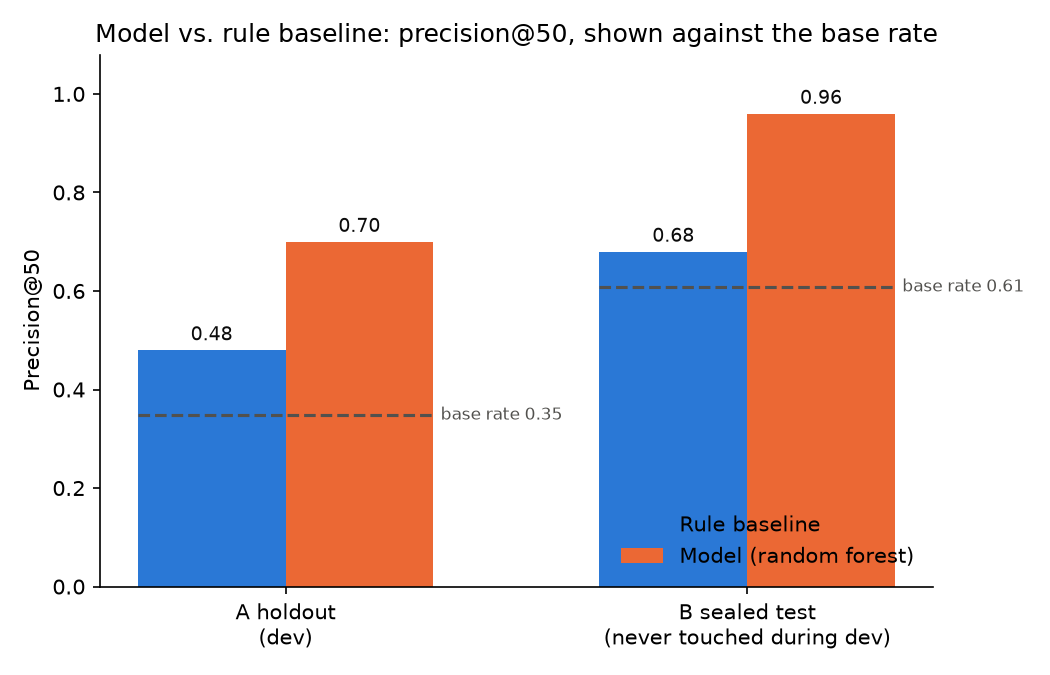

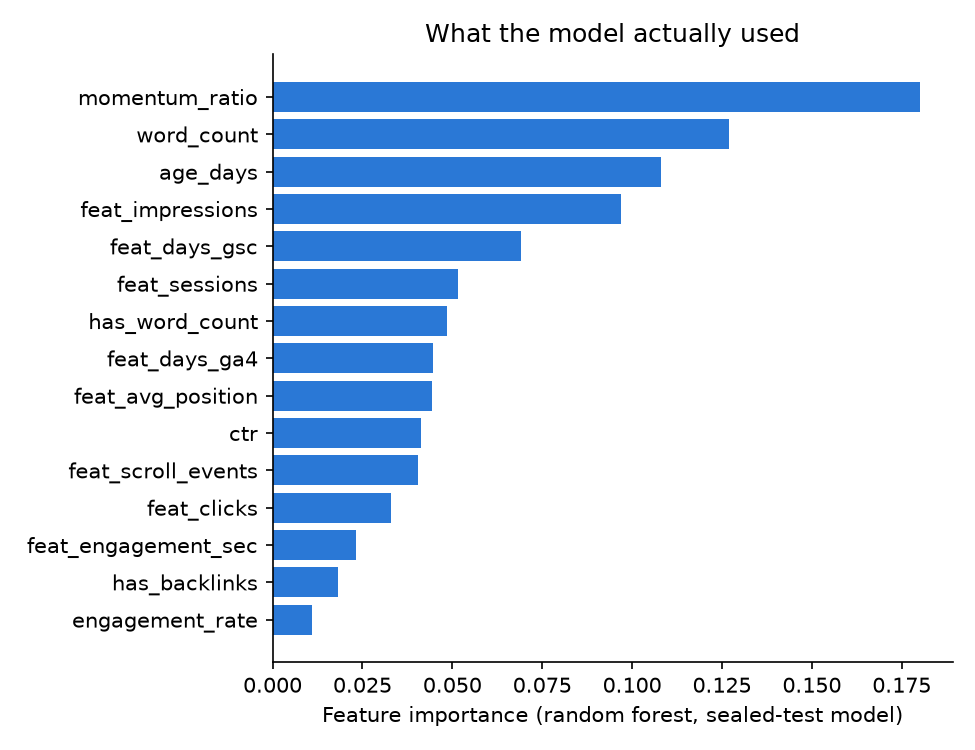

In [4]:
# Trains baseline+models on A (client-holdout split), evaluates once on the sealed B test,
# and builds the figures -- skips straight to loading results if they already exist.
import json
import subprocess
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

SCRIPTS = Path("../capstone/scripts")
OUT = Path("../outputs")
FIG = Path("../figures")

if not (OUT / "capstone_warehouse_model_results.json").exists():
    subprocess.run([sys.executable, str(SCRIPTS / "baseline_and_model.py")], check=True)
if not (FIG / "capstone_precision_at_50_comparison.png").exists():
    subprocess.run([sys.executable, str(SCRIPTS / "make_figures.py")], check=True)

results = json.load(open(OUT / "capstone_warehouse_model_results.json"))
best = results["best_model"]

table = pd.DataFrame(
    {
        "baseline_P@50": [results["baseline_A_holdout"]["precision_at_50"], results["baseline_B_sealed"]["precision_at_50"]],
        f"{best}_P@50": [results[f"{best}_A_holdout"]["precision_at_50"], results[f"{best}_B_sealed"]["precision_at_50"]],
        "base_rate": [results["baseline_A_holdout"]["base_rate"], results["baseline_B_sealed"]["base_rate"]],
        "baseline_AP": [results["baseline_A_holdout"]["average_precision"], results["baseline_B_sealed"]["average_precision"]],
        f"{best}_AP": [results[f"{best}_A_holdout"]["average_precision"], results[f"{best}_B_sealed"]["average_precision"]],
    },
    index=["A holdout", "B sealed test"],
)
display(table)
display(Image(str(FIG / "capstone_precision_at_50_comparison.png")))
display(Image(str(FIG / "capstone_feature_importance.png")))


## 5. Limitations

*What this work cannot claim.*

- **Directional, not causal:** a high decline score means "this pattern historically preceded
  a click-rate drop" — it does not mean refreshing the page will fix it, and it says nothing
  about *why* Google's ranking moved.
- **Coverage:** built on ~55 of 104 clients (those with active GSC access and full trailing
  history at both decision dates) — results may not transfer to clients with thin tracking
  history.
- **Base-rate instability is unexplained:** the decline base rate nearly doubled between the
  two snapshots (35% → 61%, two months apart). Grain and eligibility checks pass cleanly on
  both, so it isn't a query bug — but I don't know *why* it shifted, and I'm not claiming to.
  This is exactly the kind of honest "no explanation yet" the lane guide asks for.
- **Window choice is a design decision:** a 60-day label window and a 20% threshold were
  chosen for this capstone; a shorter/longer window or a different threshold could rank pages
  differently. Not tested here.
- **Careful language throughout:** every claim above is observed / measured / directional /
  decision-support — never a claim to have predicted Google's algorithm or proven a causal
  refresh effect.

In [5]:
# Backs the "coverage" limitation: how many of the 104 clients this actually covers.
from pathlib import Path

import pandas as pd

a = pd.read_parquet(Path("../capstone/cache/contract_frame_A.parquet"))
b = pd.read_parquet(Path("../capstone/cache/contract_frame_B.parquet"))
print(f"Distinct clients scored — A: {a['client_hash_id'].nunique()}, B: {b['client_hash_id'].nunique()} "
      f"(out of 104 total in dim_clients)")
print(f"Base rate A: {a['is_declining_v2'].mean():.3f} | Base rate B: {b['is_declining_v2'].mean():.3f} "
      "— the unexplained shift flagged above.")


Distinct clients scored — A: 20, B: 22 (out of 104 total in dim_clients)
Base rate A: 0.350 | Base rate B: 0.608 — the unexplained shift flagged above.


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

Pull the model's ranked top-N per client each cycle into the refresh queue, using the reason
code to brief the reviewer in one line — e.g. *"internal momentum already declining; high
demand (impressions); low CTR for its demand; page-one visibility at risk"* is a concrete,
explainable brief, not a black-box score. Given the observed lift (§4), I'd treat the top ~50
per client as strong first-pass candidates for review, with lower-ranked items as monitor-only.

**Confidence:** directional and decision-support — this ranks *risk of decline*, it does not
promise a refresh will fix it.

In [6]:
# The actual ranked-queue output a reviewer would see -- pseudonymous IDs only.
from pathlib import Path

import pandas as pd

q = pd.read_parquet(Path("../capstone/cache/ranked_queue_B.parquet"))
assert q["client_hash_id"].str.startswith("client_").all()
assert q["content_hash_id"].str.startswith("content_").all()
print("IDs confirmed pseudonymous only -- safe to show.")

q.head(10)[["client_hash_id", "content_hash_id", "model_score", "reason_code"]]


IDs confirmed pseudonymous only -- safe to show.


,client_hash_id,content_hash_id,model_score,reason_code
0,client_e547b89c05043229,content_9290be3819d8bb4f,0.989780,internal momentum already declining; high dema...
1,client_e547b89c05043229,content_0563e8d2e0a8e607,0.986346,internal momentum already declining; high dema...
2,client_e547b89c05043229,content_e8a9008af1c6376e,0.985357,internal momentum already declining; high dema...
3,client_e547b89c05043229,content_c4b883c7c76a86cd,0.982486,internal momentum already declining; high dema...
4,client_e547b89c05043229,content_97e31ebdbc7b108d,0.979775,internal momentum already declining; high dema...
5,client_e547b89c05043229,content_7b8d8b19d42076c9,0.978623,internal momentum already declining; high dema...
6,client_e547b89c05043229,content_4fcac111dc6df214,0.978453,internal momentum already declining; high dema...
7,client_e547b89c05043229,content_e185b59787350a36,0.977502,internal momentum already declining; high dema...
8,client_9958f0a7ae1df715,content_ead143532cd7e033,0.976432,internal momentum already declining; high dema...
9,client_e547b89c05043229,content_fe7d016179477af6,0.973391,internal momentum already declining; high dema...


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

- `work/figures/capstone_precision_at_50_comparison.png` — baseline vs. model, both snapshots, against base rate
- `work/figures/capstone_feature_importance.png` — what the model actually used
- `work/outputs/capstone_warehouse_model_results.json` — every metric in §4, committed as the receipt
- `work/outputs/capstone_warehouse_feature_importance.json` — the feature importances behind the chart above
- The ranked top-10 sample below — pseudonymous IDs only, safe to publish

In [7]:
# Confirm every artifact the paper needs actually exists before deploying.
from pathlib import Path

for p in sorted(Path("../figures").glob("capstone_*.png")):
    print(p, f"{p.stat().st_size:,} bytes")
for p in sorted(Path("../outputs").glob("capstone_*.json")):
    print(p, f"{p.stat().st_size:,} bytes")


..\figures\capstone_feature_importance.png 54,610 bytes
..\figures\capstone_precision_at_50_comparison.png 47,475 bytes
..\outputs\capstone_warehouse_feature_importance.json 483 bytes
..\outputs\capstone_warehouse_model_results.json 1,476 bytes


## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [x] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.


## ML-12 — Demo outline, social cut, employer summary

**5-minute demo outline:**
1. *(30s)* The problem: hundreds of thousands of content items, a handful of reviewer-hours —
   which pages get looked at first?
2. *(60s)* The data: full 78.8M-row FlyRank warehouse, two time snapshots, label computed
   fresh from future daily clicks — never a reused product field. Show the data contract.
3. *(60s)* The baseline: one transparent rule anyone can audit in a sentence.
4. *(90s)* The model vs. baseline chart — both snapshots, against base rate. Point at the
   sealed test explicitly: this number was never touched during development.
5. *(60s)* The ranked queue + reason codes — what a reviewer actually sees Monday morning.
6. *(20s)* Limits, in one breath: directional, ~55/104 clients, base rate shifted and I don't
   know why yet.

**Social-post cut (one paragraph):**
> Built a content-refresh priority model on FlyRank's full 79M-row search warehouse — not the
> sample dataset. Two honest touchstones: a transparent baseline rule, and a sealed test month
> the model never saw during training. Result: precision@50 jumped from 0.68→0.96 on that
> sealed test (base rate 0.61), with plain-language reason codes for every recommendation.
> Full write-up + repo linked below.

**Employer-facing summary (3 sentences):**
> I rebuilt a content-prioritization pipeline directly from a 79M-row raw search/analytics
> warehouse, defining my own forward-looking label instead of relying on a precomputed field,
> and validated it with a genuinely sealed, never-touched-during-development test period. The
> resulting model roughly doubled the precision of a transparent hand-written rule at picking
> which pages actually declined next, while surfacing a real, still-open data question (a
> shifting base rate) rather than hiding it. The output is a ranked, reason-coded queue built
> for a human reviewer to act on, not a black box.